In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import sys
import os

sys.path.append(os.path.abspath('../src'))
from dataset import get_data_loaders

## Loading data

In [5]:
data_dir = "../data/processed"
dataloaders, dataset_sizes, class_names = get_data_loaders(data_dir)

## Getting one batch of images from the train

In [6]:
train_features, train_labels = next(iter(dataloaders['train']))

print(f"Image batch size: {train_features.shape}")
print(f"Size of tag batch: {train_labels.shape}")

Image batch size: torch.Size([64, 3, 224, 224])
Size of tag batch: torch.Size([64])


## Function for showing an image (Denormalization)

In [7]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    
    inp = inp.numpy().transpose((1, 2, 0)) 
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    
    inp = np.clip(inp, 0, 1)
    
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

## Building a grid of images

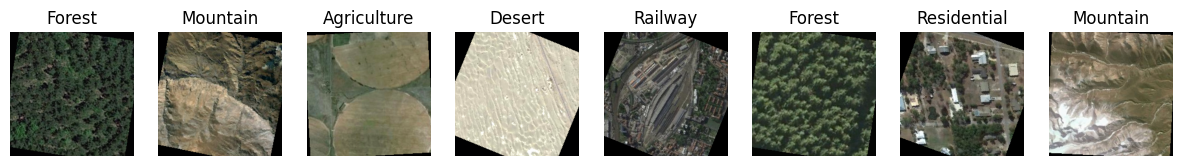

In [8]:
plt.figure(figsize=(15, 6))

num_images_to_show = 8 

for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    
    image = train_features[i]
    label = train_labels[i].item()
    
    imshow(image, title=class_names[label])

plt.show()